<a href="https://colab.research.google.com/github/Narendra-0017/AI_TraceFinder-Narendra/blob/main/NarendraChaudhari/AI_TraceFinder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
 !pip -q install tifffile pandas pillow matplotlib

from google.colab import drive
drive.mount('/content/drive')


import os, re, math, random
import numpy as np
import pandas as pd
import tifffile as tiff
from PIL import Image
import matplotlib.pyplot as plt

# ---- CONFIG ----
BASE = "/content/drive/MyDrive/DATASET"   # contains Flatfield, Official, Wikipedia
DOMAINS = ["Flatfield", "Official", "Wikipedia"]
OUT_DIR = "/content/drive/MyDrive/TraceFinder/processed_png"  # preprocessed PNGs
META_CSV = "/content/drive/MyDrive/TraceFinder/metadata.csv"
IMG_SIZE = (256, 256)  # resize target
os.makedirs(os.path.dirname(META_CSV), exist_ok=True)

Mounted at /content/drive


In [ ]:
def infer_dpi_from_path(path):
    parts = path.replace("\\","/").split("/")
    for p in reversed(parts):
        if p in ("150","300"):
            return int(p)
    m = re.match(r'(150|300)\.(tif|tiff)$', os.path.basename(path), re.IGNORECASE)
    return int(m.group(1)) if m else None

def infer_domain_scanner(path):
    parts = path.replace("\\","/").split("/")
    if "DATASET" in parts:
        i = parts.index("DATASET")
    else:
        # fallback: assume BASE split
        base_parts = BASE.replace("\\","/").split("/")
        i = len(base_parts)-1
    domain = parts[i+1] if len(parts) > i+1 else "UNKNOWN"
    scanner = parts[i+2] if len(parts) > i+2 else "UNKNOWN"
    return domain, scanner

rows = []
for domain in DOMAINS:
    root_domain = os.path.join(BASE, domain)
    if not os.path.isdir(root_domain):
        print("Missing:", root_domain);
        continue

    for root, _, files in os.walk(root_domain):
        for f in files:
            if f.lower().endswith((".tif",".tiff")):
                path = os.path.join(root, f)
                dpi = infer_dpi_from_path(path)
                dom, scanner = infer_domain_scanner(path)
                try:
                    arr = tiff.imread(path)
                    h, w = arr.shape[:2]
                    ch = 1 if arr.ndim==2 else arr.shape[2]
                    dtype = str(arr.dtype)
                    mn, mx = float(np.min(arr)), float(np.max(arr))
                    mean, std = float(np.mean(arr)), float(np.std(arr))
                except Exception as e:
                    h=w=ch=None; dtype="error"; mn=mx=mean=std=None

                mb = os.path.getsize(path)/(1024*1024)
                rows.append(dict(domain=dom, scanner=scanner, dpi=dpi, path=path,
                                 mb=round(mb,2), width=w, height=h, channels=ch,
                                 dtype=dtype, min=mn, max=mx, mean=mean, std=std))

df = pd.DataFrame(rows).sort_values(["domain","scanner","dpi","path"]).reset_index(drop=True)
print("Indexed files:", len(df))
df.to_csv(META_CSV, index=False)
df.head()


Indexed files: 4591


,domain,scanner,dpi,path,mb,width,height,channels,dtype,min,max,mean,std
0,Flatfield,Canon120-1,150.0,/content/drive/MyDrive/DATASET/Flatfield/Canon...,6.22,1240.0,1752.0,3.0,uint8,139.0,255.0,254.999235,0.143073
1,Flatfield,Canon120-1,300.0,/content/drive/MyDrive/DATASET/Flatfield/Canon...,24.90,2480.0,3508.0,3.0,uint8,80.0,255.0,254.998830,0.200240
2,Flatfield,Canon120-2,150.0,/content/drive/MyDrive/DATASET/Flatfield/Canon...,24.90,2480.0,3508.0,3.0,uint8,32.0,255.0,254.676827,7.929205
3,Flatfield,Canon120-2,300.0,/content/drive/MyDrive/DATASET/Flatfield/Canon...,24.90,2480.0,3508.0,3.0,uint8,32.0,255.0,254.675428,7.950465
4,Flatfield,Canon220,150.0,/content/drive/MyDrive/DATASET/Flatfield/Canon...,6.22,1240.0,1752.0,3.0,uint8,26.0,255.0,254.611143,9.087963


In [ ]:
import pandas as pd

META_CSV = "/content/drive/MyDrive/TraceFinder/metadata.csv"
df = pd.read_csv(META_CSV)

print("Loaded rows:", len(df))
df.head()


Loaded rows: 4591


,domain,scanner,dpi,path,mb,width,height,channels,dtype,min,max,mean,std
0,Flatfield,Canon120-1,150.0,/content/drive/MyDrive/DATASET/Flatfield/Canon...,6.22,1240.0,1752.0,3.0,uint8,139.0,255.0,254.999235,0.143073
1,Flatfield,Canon120-1,300.0,/content/drive/MyDrive/DATASET/Flatfield/Canon...,24.90,2480.0,3508.0,3.0,uint8,80.0,255.0,254.998830,0.200240
2,Flatfield,Canon120-2,150.0,/content/drive/MyDrive/DATASET/Flatfield/Canon...,24.90,2480.0,3508.0,3.0,uint8,32.0,255.0,254.676827,7.929205
3,Flatfield,Canon120-2,300.0,/content/drive/MyDrive/DATASET/Flatfield/Canon...,24.90,2480.0,3508.0,3.0,uint8,32.0,255.0,254.675428,7.950465
4,Flatfield,Canon220,150.0,/content/drive/MyDrive/DATASET/Flatfield/Canon...,6.22,1240.0,1752.0,3.0,uint8,26.0,255.0,254.611143,9.087963


EDA

,domain,scanner,dpi,n
0,Flatfield,Canon120-1,150.0,1
1,Flatfield,Canon120-1,300.0,1
2,Flatfield,Canon120-2,150.0,1
3,Flatfield,Canon120-2,300.0,1
4,Flatfield,Canon220,150.0,1
...,...,...,...,...
61,Wikipedia,EpsonV39-2,300.0,108
62,Wikipedia,EpsonV550,150.0,108
63,Wikipedia,EpsonV550,300.0,108
64,Wikipedia,HP,150.0,108


domain
Flatfield      23
Official     2200
Wikipedia    2368
dtype: int64
dpi
150.0    2300
300.0    2290
NaN         1
Name: count, dtype: int64
width   height
2480.0  3508.0    1871
1240.0  1754.0     837
        1752.0     626
1236.0  1754.0     420
1239.0  1754.0     208
2478.0  3508.0     208
2481.0  3487.0     146
1240.0  1743.0     137
        1727.0      72
2481.0  3471.0      62
Name: count, dtype: int64


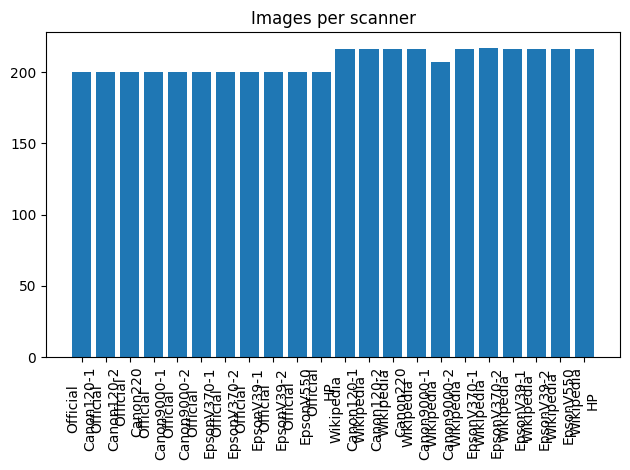

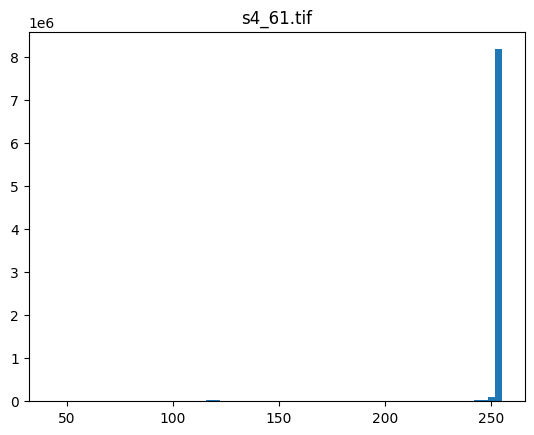

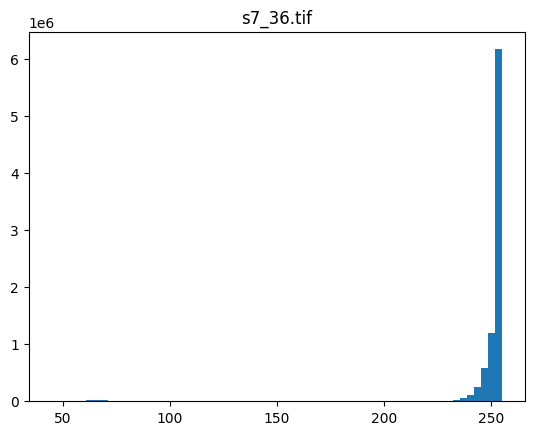

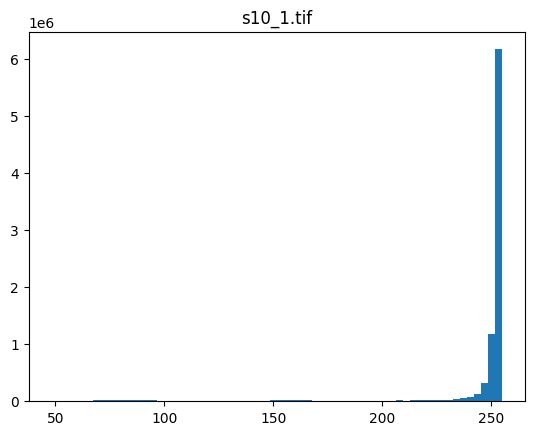

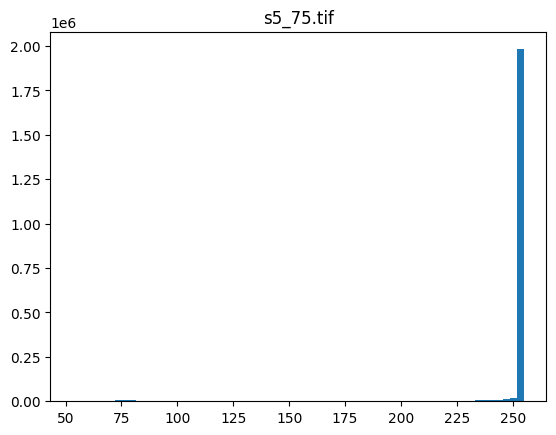

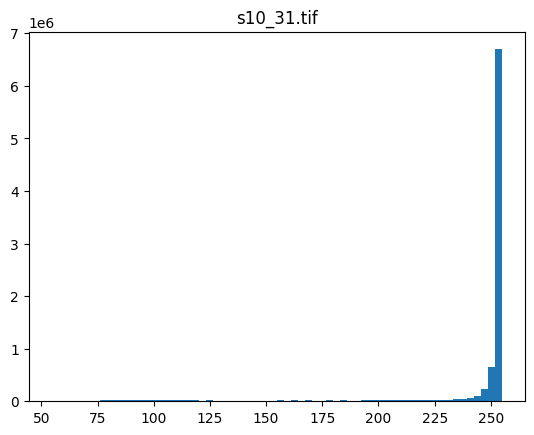

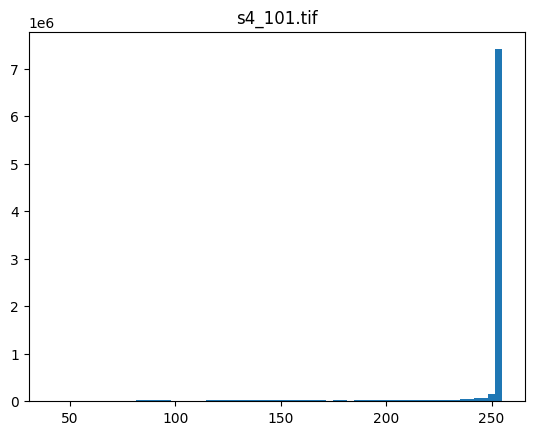

In [ ]:
# Counts per (domain, scanner, dpi)
counts = df.groupby(["domain","scanner","dpi"]).size().rename("n").reset_index()
display(counts.sort_values(["domain","scanner","dpi"]))

# Overall per-domain counts
print(df.groupby("domain").size())

# DPI distribution
print(df["dpi"].value_counts(dropna=False))

# Resolutions seen
print(df[["width","height"]].dropna().value_counts().head(10))

# Bar plot: images per scanner (Official + Wikipedia only)
subset = df[df["domain"].isin(["Official","Wikipedia"])]
scanner_counts = subset.groupby(["domain","scanner"]).size().rename("n").reset_index()

plt.figure()
plt.bar(range(len(scanner_counts)), scanner_counts["n"])
plt.xticks(range(len(scanner_counts)),
           [f'{d}\n{s}' for d,s in zip(scanner_counts["domain"], scanner_counts["scanner"])],
           rotation=90)
plt.title("Images per scanner")
plt.tight_layout()
plt.show()

# Intensity histogram from a few random files (non-Flatfield)
sample_paths = subset["path"].sample(min(6, len(subset)), random_state=0).tolist()
for p in sample_paths:
    arr = tiff.imread(p)
    if arr.ndim==3:
        arr = arr[...,:3].mean(-1)
    plt.figure()
    plt.hist(arr.ravel(), bins=64)
    plt.title(os.path.basename(p))
    plt.show()


Preprocessing

In [ ]:
def to_uint8_image(arr):
    # robust channel squeeze
    if arr.ndim==3:
        # handle last-channel or first-channel layouts
        if arr.shape[-1] in (3,4):
            arr = arr[...,:3].mean(-1)
        elif arr.shape[0] in (3,4):
            arr = arr[:3,...].mean(0)
        else:
            arr = arr.squeeze()
    arr = np.asarray(arr)

    # scale to 0..255 safely (handles 16-bit TIFFs)
    amin, amax = float(arr.min()), float(arr.max())
    scale = 255.0 / (amax - amin) if amax != amin else 1.0
    arr8 = np.clip((arr - amin) * scale, 0, 255).astype(np.uint8)
    return arr8

def preprocess_and_save(row):
    src = row["path"]
    dest = os.path.join(OUT_DIR, row["domain"], row["scanner"], str(row["dpi"] or "na"),
                        os.path.splitext(os.path.basename(src))[0] + ".png")
    os.makedirs(os.path.dirname(dest), exist_ok=True)

    arr = tiff.imread(src)
    img8 = to_uint8_image(arr)
    im = Image.fromarray(img8).resize(IMG_SIZE, Image.BICUBIC)
    im.save(dest)
    return dest

# Process Official & Wikipedia (Flatfield are blank refs — keep but optional)
proc_df = df.copy()
proc_df["out_path"] = None
for i, row in proc_df.iterrows():
    try:
        proc_df.at[i, "out_path"] = preprocess_and_save(row)
    except Exception as e:
        print("Failed:", row["path"], "->", e)

proc_df.to_csv(META_CSV.replace(".csv","_with_out.csv"), index=False)
print("Saved PNGs under:", OUT_DIR)


Failed: /content/drive/MyDrive/DATASET/Flatfield/EpsonV39-1/._150.tif -> not a TIFF file b'\x00\x05\x16\x07'


KeyboardInterrupt: 

In [ ]:
import os
from PIL import Image
import tifffile as tiff
import numpy as np

# Paths
BASE = "/content/drive/MyDrive/DATASET"
OUT_DIR = "/content/drive/MyDrive/TraceFinder/processed_png"
IMG_SIZE = (256, 256)

def preprocess_and_save(src, domain, scanner, dpi):
    # Skip junk files
    if os.path.basename(src).startswith("._"):
        return None

    # Destination path
    fname = os.path.splitext(os.path.basename(src))[0] + ".png"
    dest = os.path.join(OUT_DIR, domain, scanner, str(dpi or "na"), fname)

    # Skip if already processed
    if os.path.exists(dest):
        return dest

    try:
        # Read TIFF
        arr = tiff.imread(src)

        # Convert to grayscale safely
        if arr.ndim == 3:
            arr = arr[..., :3].mean(-1)
        arr = np.asarray(arr)

        # Scale to 8-bit
        amin, amax = float(arr.min()), float(arr.max())
        scale = 255.0 / (amax - amin) if amax != amin else 1.0
        arr8 = np.clip((arr - amin) * scale, 0, 255).astype(np.uint8)

        # Resize & save
        im = Image.fromarray(arr8).resize(IMG_SIZE, Image.BICUBIC)
        os.makedirs(os.path.dirname(dest), exist_ok=True)
        im.save(dest)
        return dest
    except Exception as e:
        print("Failed:", src, "->", e)
        return None

# Process Official + Wikipedia
domains_to_process = ["Official", "Wikipedia"]
batch_size = 500
for domain in domains_to_process:
    domain_path = os.path.join(BASE, domain)
    for scanner in os.listdir(domain_path):
        scanner_path = os.path.join(domain_path, scanner)
        if not os.path.isdir(scanner_path): continue

        for dpi_folder in os.listdir(scanner_path):
            dpi_path = os.path.join(scanner_path, dpi_folder)
            if not os.path.isdir(dpi_path): continue

            files = [os.path.join(dpi_path, f) for f in os.listdir(dpi_path) if f.lower().endswith(".tif")]

            # Batch loop
            for start in range(0, len(files), batch_size):
                end = min(start+batch_size, len(files))
                print(f"[{domain}/{scanner}/{dpi_folder}] Processing {start}:{end}/{len(files)}")

                for src in files[start:end]:
                    preprocess_and_save(src, domain, scanner, dpi_folder)


[Official/Canon120-1/150] Processing 0:100/100
[Official/Canon120-1/300] Processing 0:100/100
[Official/Canon220/300] Processing 0:100/100
[Official/Canon220/150] Processing 0:100/100
[Official/EpsonV370-2/300] Processing 0:100/100
[Official/EpsonV370-2/150] Processing 0:100/100
[Official/EpsonV370-1/150] Processing 0:100/100
[Official/EpsonV370-1/300] Processing 0:100/100
[Official/Canon9000-2/150] Processing 0:100/100
[Official/Canon9000-2/300] Processing 0:100/100
[Official/Canon120-2/150] Processing 0:100/100
[Official/Canon120-2/300] Processing 0:100/100
[Official/HP/300] Processing 0:100/100
[Official/HP/150] Processing 0:100/100
[Official/EpsonV39-2/150] Processing 0:100/100
[Official/EpsonV39-2/300] Processing 0:100/100
[Official/EpsonV550/150] Processing 0:100/100
[Official/EpsonV550/300] Processing 0:100/100
[Official/Canon9000-1/150] Processing 0:100/100
[Official/Canon9000-1/300] Processing 0:100/100
[Official/EpsonV39-1/150] Processing 0:100/100
[Official/EpsonV39-1/300] P

KeyboardInterrupt: 

EDA after preprocessing

Total processed images: 2560

Counts per scanner:
scanner
Canon120-1     400
Canon120-2     360
Canon220       200
Canon9000-1    200
Canon9000-2    200
EpsonV370-1    200
EpsonV370-2    200
EpsonV39-1     200
EpsonV39-2     200
EpsonV550      200
HP             200
dtype: int64

Counts per (scanner, dpi):
scanner      dpi  
Canon120-1   150      100
             150.0    100
             300      100
             300.0    100
Canon120-2   150      100
             150.0    100
             300      100
             300.0     60
Canon220     150      100
             300      100
Canon9000-1  150      100
             300      100
Canon9000-2  150      100
             300      100
EpsonV370-1  150      100
             300      100
EpsonV370-2  150      100
             300      100
EpsonV39-1   150      100
             300      100
EpsonV39-2   150      100
             300      100
EpsonV550    150      100
             300      100
HP           150      100
             300      1

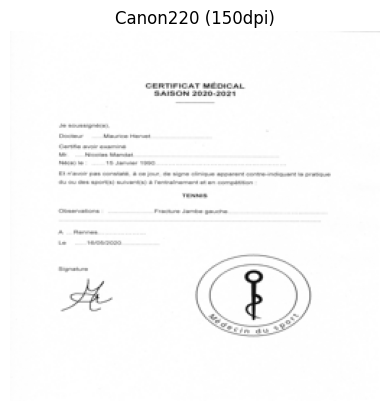

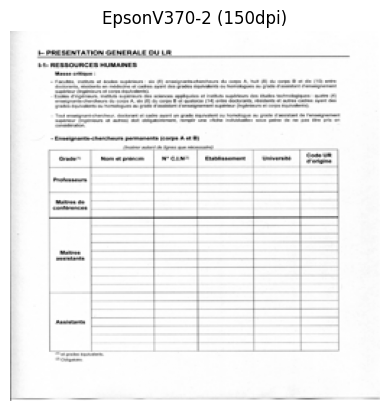

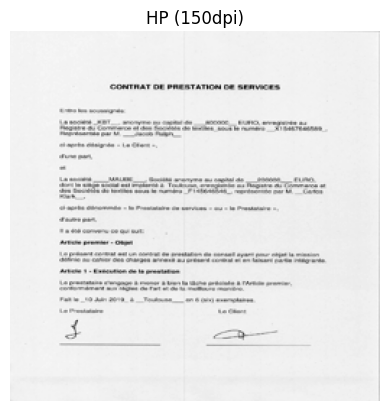

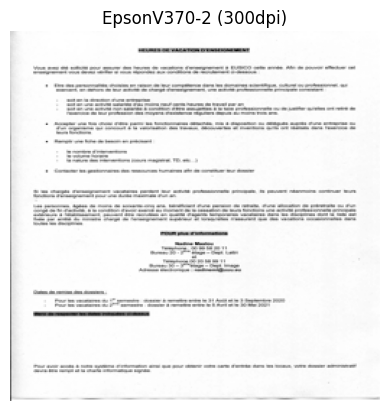

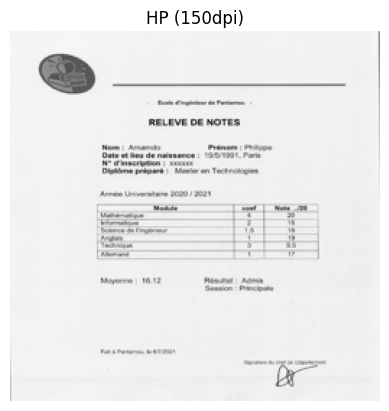

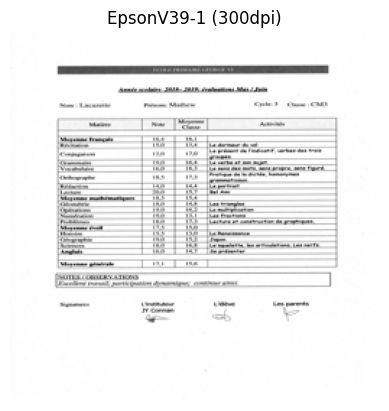

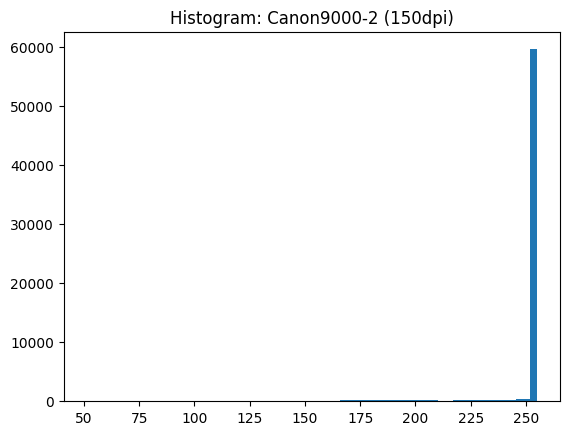

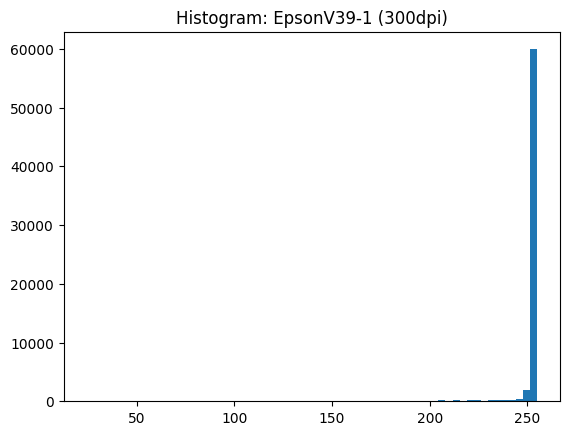

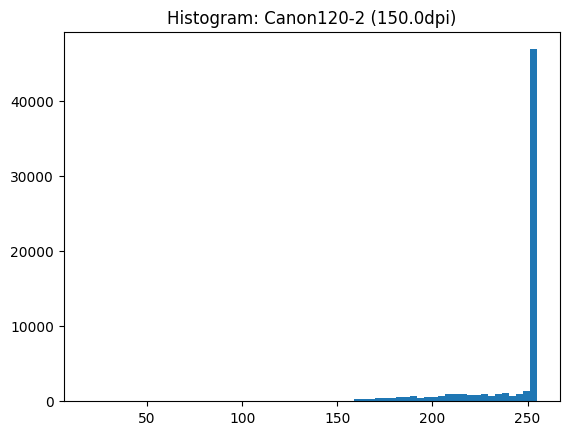

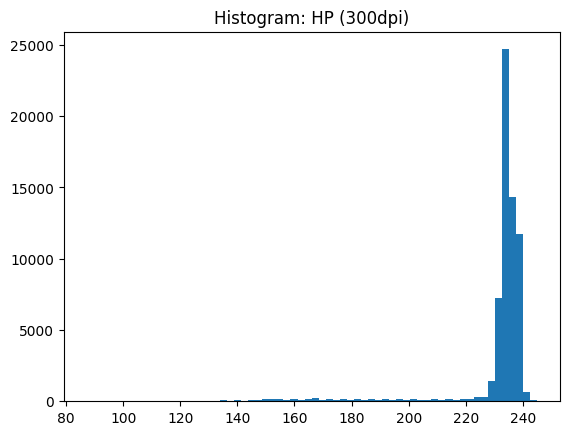

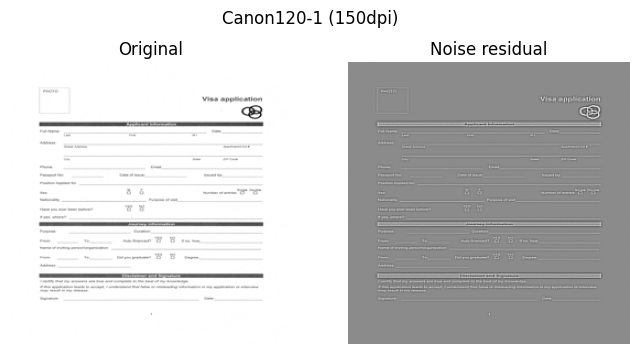

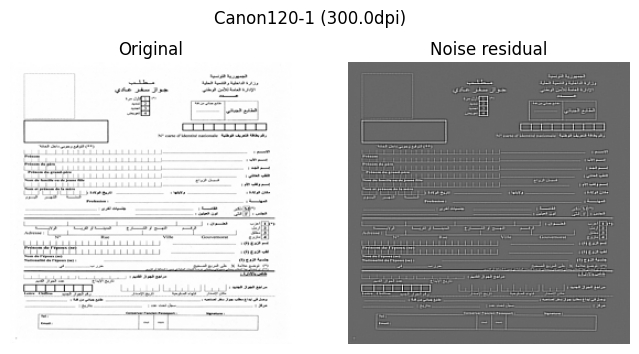

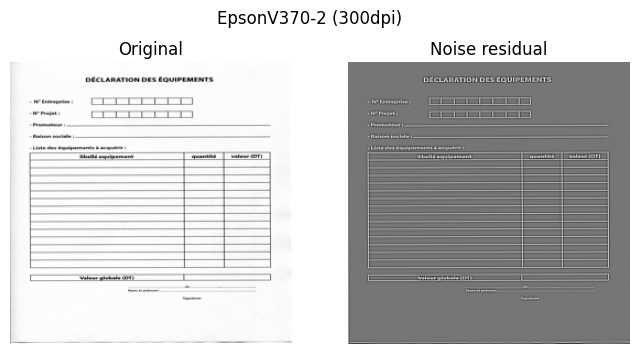

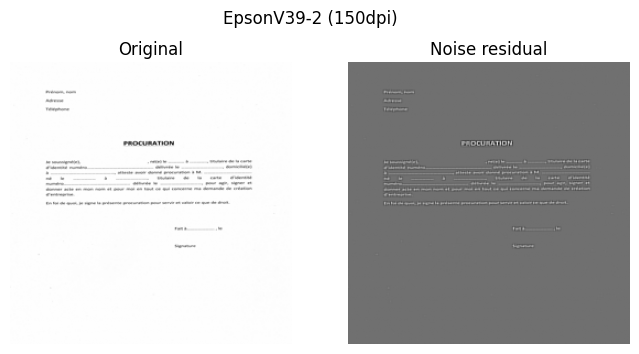

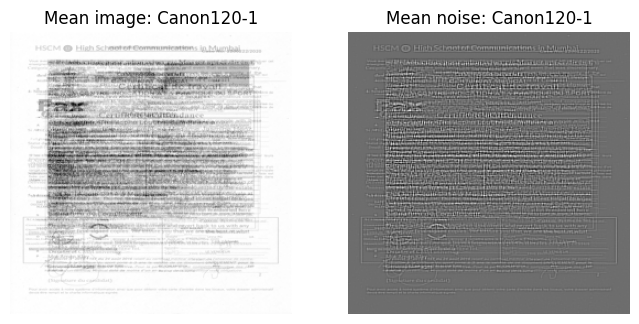

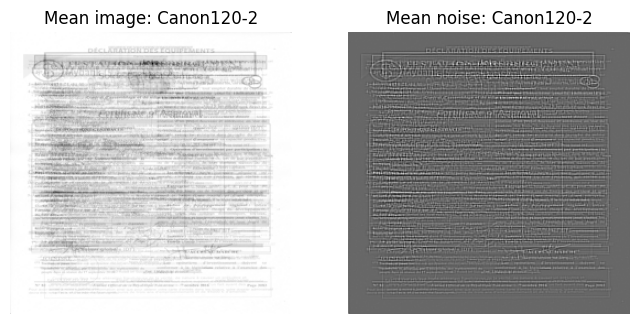

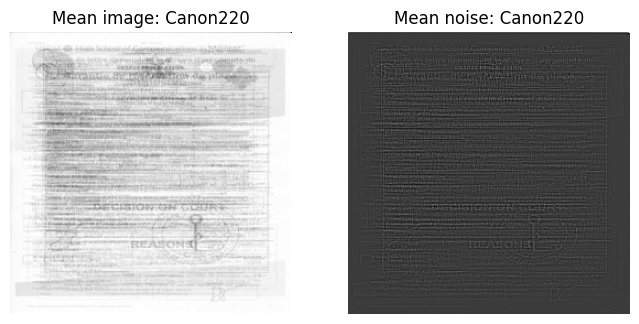

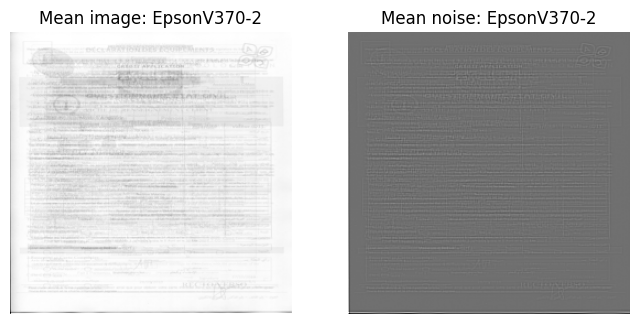

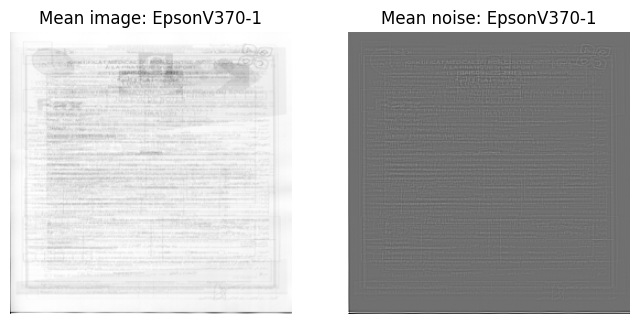

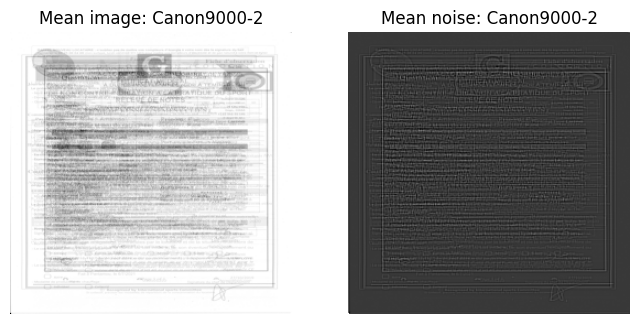

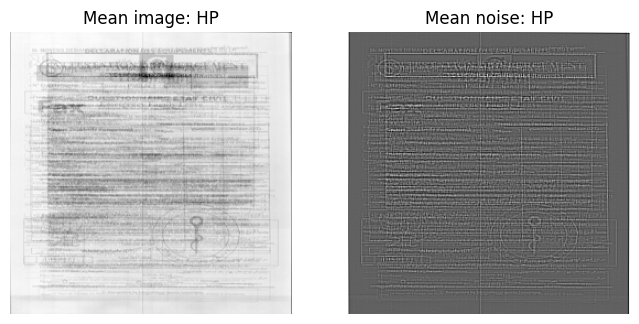

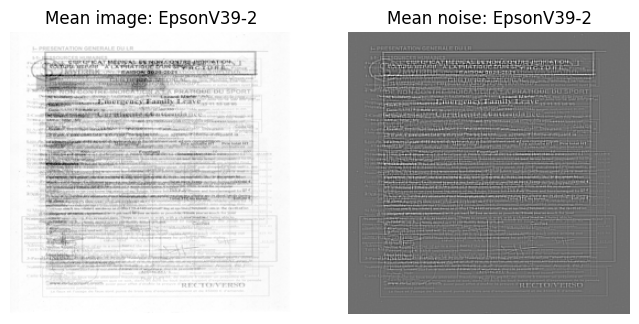

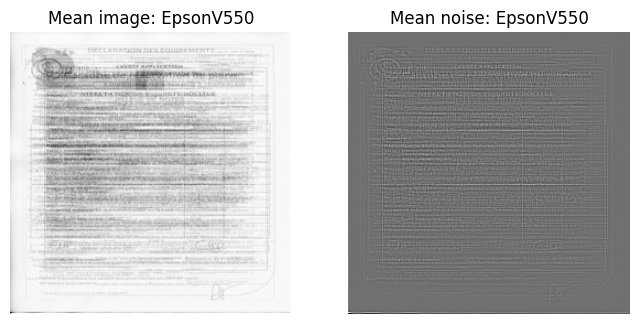

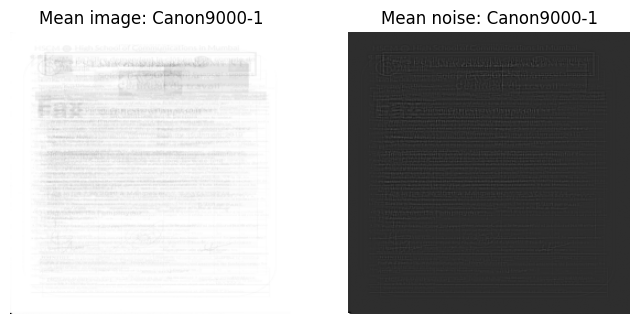

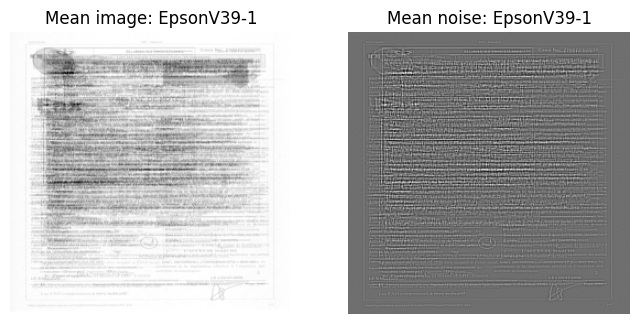

In [ ]:
import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import cv2  # for filtering

# Path to processed Official dataset
PROC_DIR = "/content/drive/MyDrive/TraceFinder/processed_png/Official"

# Build metadata from processed PNGs
rows = []
for scanner in os.listdir(PROC_DIR):
    scanner_path = os.path.join(PROC_DIR, scanner)
    if not os.path.isdir(scanner_path): continue
    for dpi in os.listdir(scanner_path):
        dpi_path = os.path.join(scanner_path, dpi)
        if not os.path.isdir(dpi_path): continue
        for f in os.listdir(dpi_path):
            if f.lower().endswith(".png"):
                rows.append({
                    "scanner": scanner,
                    "dpi": dpi,
                    "path": os.path.join(dpi_path, f)
                })
df = pd.DataFrame(rows)
print("Total processed images:", len(df))
df.head()

# --- Counts ---
print("\nCounts per scanner:")
print(df.groupby("scanner").size())

print("\nCounts per (scanner, dpi):")
print(df.groupby(["scanner","dpi"]).size())

# --- Sample images ---
def show_samples(n=6):
    sample = df.sample(n)
    for _, row in sample.iterrows():
        im = Image.open(row["path"])
        plt.imshow(im, cmap="gray")
        plt.title(f'{row["scanner"]} ({row["dpi"]}dpi)')
        plt.axis("off")
        plt.show()
show_samples(6)

# --- Intensity histograms ---
sample = df.sample(4, random_state=1)
for _, row in sample.iterrows():
    arr = np.array(Image.open(row["path"]))
    plt.hist(arr.ravel(), bins=64)
    plt.title(f'Histogram: {row["scanner"]} ({row["dpi"]}dpi)')
    plt.show()

# --- Noise residuals (simple high-pass filter) ---
def highpass(img_array):
    return cv2.Laplacian(img_array, cv2.CV_64F, ksize=3)

sample = df.sample(4, random_state=2)
for _, row in sample.iterrows():
    arr = np.array(Image.open(row["path"]))
    noise = highpass(arr)
    plt.figure(figsize=(8,4))
    plt.subplot(1,2,1)
    plt.imshow(arr, cmap="gray")
    plt.title("Original")
    plt.axis("off")
    plt.subplot(1,2,2)
    plt.imshow(noise, cmap="gray")
    plt.title("Noise residual")
    plt.axis("off")
    plt.suptitle(f'{row["scanner"]} ({row["dpi"]}dpi)')
    plt.show()

# --- Per-scanner mean image & mean noise ---
for scanner in df["scanner"].unique():
    subset = df[df["scanner"] == scanner].sample(min(20, len(df[df["scanner"] == scanner])))  # limit for speed
    imgs = [np.array(Image.open(p)) for p in subset["path"]]
    arr = np.stack(imgs).astype("float32")
    mean_img = arr.mean(axis=0)

    noises = [highpass(im) for im in imgs]
    mean_noise = np.stack(noises).mean(axis=0)

    plt.figure(figsize=(8,4))
    plt.subplot(1,2,1)
    plt.imshow(mean_img, cmap="gray")
    plt.title(f"Mean image: {scanner}")
    plt.axis("off")
    plt.subplot(1,2,2)
    plt.imshow(mean_noise, cmap="gray")
    plt.title(f"Mean noise: {scanner}")
    plt.axis("off")
    plt.show()


In [ ]:
# Colab cell (bash)
!pip -q install tifffile bm3d scikit-image xgboost shap
# bm3d pip may be slow/optional. If pip bm3d unavailable, code falls back to wavelet denoise.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 862.0/862.0 kB 20.2 MB/s eta 0:00:00


PRNu

In [ ]:
import os
import cv2
import numpy as np
from tqdm import tqdm
from skimage.restoration import denoise_wavelet
import tifffile as tiff

# CONFIG
BASE_DIR = "/content/drive/MyDrive/DATASET"   # contains Flatfield/, Official/, Wikipedia/
OUTPUT_DIR = "/content/drive/MyDrive/PRNU_Residual"
RESIZE_SHAPE = (256, 256)

os.makedirs(OUTPUT_DIR, exist_ok=True)

def get_prnu(image):
    image = image.astype(np.float32) / 255.0

    if image.ndim == 2:  # grayscale
        denoised = denoise_wavelet(image, channel_axis=None,
                                   method='BayesShrink', mode='soft',
                                   rescale_sigma=True)
    else:  # RGB
        denoised = denoise_wavelet(image, channel_axis=-1, convert2ycbcr=True,
                                   method='BayesShrink', mode='soft',
                                   rescale_sigma=True)

    residual = image - denoised
    residual = residual - residual.mean()
    std = residual.std()
    if std > 1e-6:
        residual = residual / std
    return residual

def process_dataset(subset):
    """ subset = 'Flatfield', 'Official', or 'Wikipedia' """
    input_dir = os.path.join(BASE_DIR, subset)
    output_dir = os.path.join(OUTPUT_DIR, subset)
    os.makedirs(output_dir, exist_ok=True)

    all_files = []
    for root, _, files in os.walk(input_dir):
        for file in files:
            if file.lower().endswith((".tif", ".tiff")) and not file.startswith("._"):
                all_files.append(os.path.join(root, file))

    print(f"[{subset}] Found {len(all_files)} TIFFs")

    for f in tqdm(all_files, desc=f"Processing {subset}"):
        try:
            # skip if already processed
            save_path = os.path.join(output_dir, os.path.relpath(f, input_dir)) + ".npy"
            if os.path.exists(save_path):
                continue

            img = tiff.imread(f)
            if img is None:
                continue

            # grayscale
            if img.ndim == 3:
                if img.shape[-1] in (3,4):
                    img = img[...,:3].mean(-1)
                else:
                    img = img.mean(0)

            residual = get_prnu(img)

            # resize + compress
            residual_small = cv2.resize(residual, RESIZE_SHAPE, interpolation=cv2.INTER_CUBIC)

            os.makedirs(os.path.dirname(save_path), exist_ok=True)
            np.save(save_path, residual_small.astype(np.float16))

            # also save PNG for visualization
            vis_path = save_path.replace(".npy", ".png")
            res_norm = (residual_small - residual_small.min()) / (residual_small.max() - residual_small.min() + 1e-8)
            res_uint8 = (res_norm * 255).astype(np.uint8)
            cv2.imwrite(vis_path, res_uint8)

        except Exception as e:
            print(f"Failed: {f} -> {e}")

# Run for all three datasets
process_dataset("Flatfield")
process_dataset("Official")
process_dataset("Wikipedia")


[Flatfield] Found 22 TIFFs


Processing Flatfield: 100%|██████████| 22/22 [00:00<00:00, 1872.99it/s]


[Official] Found 2200 TIFFs


Processing Official: 100%|██████████| 2200/2200 [00:01<00:00, 1593.39it/s]


[Wikipedia] Found 2368 TIFFs


Processing Wikipedia:  14%|█▎        | 324/2368 [09:02<1:19:58,  2.35s/it]

Failed: /content/drive/MyDrive/DATASET/Wikipedia/EpsonV550/300/s10_10.tif -> <COMPRESSION.LZW: 5> requires the 'imagecodecs' package


Processing Wikipedia:  18%|█▊        | 432/2368 [11:59<43:25,  1.35s/it]

Failed: /content/drive/MyDrive/DATASET/Wikipedia/EpsonV550/150/s10_10.tif -> <COMPRESSION.LZW: 5> requires the 'imagecodecs' package


Processing Wikipedia: 100%|██████████| 2368/2368 [1:15:26<00:00,  1.91s/it]


Flatfield Templates for each scanner

In [ ]:
import os
import numpy as np
from tqdm import tqdm

# CONFIG
FLATFIELD_DIR = "/content/drive/MyDrive/PRNU_Residual/Flatfield"
TEMPLATE_DIR = "/content/drive/MyDrive/PRNU_Residual/Templates"
os.makedirs(TEMPLATE_DIR, exist_ok=True)

def build_templates():
    scanner_templates = {}
    for scanner in sorted(os.listdir(FLATFIELD_DIR)):
        scanner_path = os.path.join(FLATFIELD_DIR, scanner)
        if not os.path.isdir(scanner_path):
            continue

        print(f"Building template for scanner: {scanner}")
        residuals = []

        # Walk through scanner subfolders (like dpi folders)
        for root, _, files in os.walk(scanner_path):
            for f in files:
                if f.endswith(".npy"):
                    try:
                        arr = np.load(os.path.join(root, f)).astype(np.float32)
                        arr = arr - arr.mean()
                        std = arr.std()
                        if std > 1e-6:
                            arr = arr / std
                        residuals.append(arr)
                    except Exception as e:
                        print("Failed:", f, "->", e)

        if residuals:
            avg_template = np.mean(residuals, axis=0)
            # normalize template
            avg_template = avg_template - avg_template.mean()
            std = avg_template.std()
            if std > 1e-6:
                avg_template = avg_template / std
            # save
            save_path = os.path.join(TEMPLATE_DIR, f"{scanner}_template.npy")
            np.save(save_path, avg_template.astype(np.float32))
            scanner_templates[scanner] = save_path
            print(f"Saved template for {scanner} -> {save_path}")
        else:
            print(f"No residuals found for scanner {scanner}")

    return scanner_templates

templates = build_templates()
print("\n✅ Templates built for scanners:", list(templates.keys()))


Building template for scanner: Canon120-1
Saved template for Canon120-1 -> /content/drive/MyDrive/PRNU_Residual/Templates/Canon120-1_template.npy
Building template for scanner: Canon120-2
Saved template for Canon120-2 -> /content/drive/MyDrive/PRNU_Residual/Templates/Canon120-2_template.npy
Building template for scanner: Canon220
Saved template for Canon220 -> /content/drive/MyDrive/PRNU_Residual/Templates/Canon220_template.npy
Building template for scanner: Canon9000-1
Saved template for Canon9000-1 -> /content/drive/MyDrive/PRNU_Residual/Templates/Canon9000-1_template.npy
Building template for scanner: Canon9000-2
Saved template for Canon9000-2 -> /content/drive/MyDrive/PRNU_Residual/Templates/Canon9000-2_template.npy
Building template for scanner: EpsonV370-1
Saved template for EpsonV370-1 -> /content/drive/MyDrive/PRNU_Residual/Templates/EpsonV370-1_template.npy
Building template for scanner: EpsonV370-2
Saved template for EpsonV370-2 -> /content/drive/MyDrive/PRNU_Residual/Templat

extract correlation features b/w flatefield and off,wiki

In [ ]:
import os, glob
import numpy as np
import pandas as pd
from tqdm import tqdm

# CONFIG
TEMPLATE_DIR = "/content/drive/MyDrive/PRNU_Residual/Templates"
RESIDUAL_BASE = "/content/drive/MyDrive/PRNU_Residual"   # contains Official/, Wikipedia/
OUT_DIR = "/content/drive/MyDrive/TraceFinder/features"
os.makedirs(OUT_DIR, exist_ok=True)

# Load templates
templates = {}
for p in glob.glob(os.path.join(TEMPLATE_DIR, "*_template.npy")):
    name = os.path.basename(p).replace("_template.npy", "")
    t = np.load(p).astype(np.float32)
    t = t - t.mean()
    std = t.std()
    if std > 1e-8:
        t = t / std
    templates[name] = t.flatten()

tpl_names = list(templates.keys())
tpl_vecs = np.stack([templates[n] for n in tpl_names], axis=0)
tpl_norms = np.linalg.norm(tpl_vecs, axis=1) + 1e-12

def correlation_features(domain_name):
    rows = []
    domain_dir = os.path.join(RESIDUAL_BASE, domain_name)
    for root, _, files in os.walk(domain_dir):
        for f in files:
            if not f.endswith(".npy"):
                continue
            path = os.path.join(root, f)
            # infer true scanner from path
            parts = path.replace("\\","/").split("/")
            try:
                i = parts.index(domain_name)
                scanner_true = parts[i+1]
            except ValueError:
                scanner_true = "UNKNOWN"

            try:
                r = np.load(path).astype(np.float32)
                r = r - r.mean()
                rr = r.flatten()
                nr = np.linalg.norm(rr) + 1e-12
                dots = tpl_vecs @ rr
                corrs = dots / (tpl_norms * nr)

                best_idx = int(np.argmax(corrs))
                pred = tpl_names[best_idx]

                row = {
                    "domain": domain_name,
                    "path": path,
                    "scanner_true": scanner_true,
                    "pred": pred,
                    "corr_best": float(corrs[best_idx])
                }
                for name, c in zip(tpl_names, corrs):
                    row[f"corr__{name}"] = float(c)
                rows.append(row)
            except Exception as e:
                print("Failed:", path, "->", e)

    df = pd.DataFrame(rows)
    save_path = os.path.join(OUT_DIR, f"corr_{domain_name.lower()}.csv")
    df.to_csv(save_path, index=False)
    print(f"✅ Saved {domain_name} correlations -> {save_path} ({df.shape})")
    return df

df_off = correlation_features("Official")
df_wiki = correlation_features("Wikipedia")


✅ Saved Official correlations -> /content/drive/MyDrive/TraceFinder/features/corr_official.csv ((2200, 16))
✅ Saved Wikipedia correlations -> /content/drive/MyDrive/TraceFinder/features/corr_wikipedia.csv ((2366, 16))


Code for FFT + LBP + Correlation Features

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm
from skimage.feature import local_binary_pattern
from scipy.fftpack import fft2, fftshift

# CONFIG
PRNU_DIR = "/content/drive/MyDrive/PRNU_Residual"   # contains Flatfield, Official, Wikipedia
FEATURES_DIR = "/content/drive/MyDrive/TraceFinder/features"
os.makedirs(FEATURES_DIR, exist_ok=True)

LBP_POINTS = 24
LBP_RADIUS = 3
LBP_NBINS = LBP_POINTS + 2
FFT_SIZE = 64   # crop FFT center region

def extract_fft_features(img):
    """ Extract magnitude spectrum from FFT """
    f = fft2(img)
    fshift = fftshift(f)
    mag = np.abs(fshift)

    # crop central region
    center = mag.shape[0] // 2
    half = FFT_SIZE // 2
    cropped = mag[center-half:center+half, center-half:center+half]

    # normalize
    cropped = np.log1p(cropped)
    return cropped.flatten()

def extract_lbp_features(img):
    """ LBP histogram """
    lbp = local_binary_pattern(img, LBP_POINTS, LBP_RADIUS, method="uniform")
    hist, _ = np.histogram(lbp.ravel(), bins=LBP_NBINS, range=(0, LBP_NBINS))
    hist = hist.astype("float")
    hist /= (hist.sum() + 1e-6)
    return hist

def process_subset(subset):
    input_dir = os.path.join(PRNU_DIR, subset)
    all_files = []
    for root, _, files in os.walk(input_dir):
        for f in files:
            if f.endswith(".npy"):
                all_files.append(os.path.join(root, f))

    print(f"[{subset}] Found {len(all_files)} PRNU residuals")
    features = []

    for f in tqdm(all_files, desc=f"Processing {subset}"):
        try:
            img = np.load(f)
            if img is None:
                continue

            # ensure grayscale float32
            if img.ndim > 2:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            img = img.astype(np.float32)

            fft_feat = extract_fft_features(img)
            lbp_feat = extract_lbp_features(img)

            row = {
                "path": f,
                "scanner": f.split("/")[-3],  # Flatfield/Official/Wikipedia/scanner/...
                "subset": subset
            }
            row.update({f"fft_{i}": v for i, v in enumerate(fft_feat)})
            row.update({f"lbp_{i}": v for i, v in enumerate(lbp_feat)})
            features.append(row)
        except Exception as e:
            print(f"Failed: {f} -> {e}")

    df = pd.DataFrame(features)
    out_csv = os.path.join(FEATURES_DIR, f"features_{subset.lower()}.csv")
    df.to_csv(out_csv, index=False)
    print(f"Saved {out_csv}, shape={df.shape}")
    return df

# Process Official + Wikipedia
df_official = process_subset("Official")
df_wiki = process_subset("Wikipedia")

# Merge into one training dataset
df_all = pd.concat([df_official, df_wiki], ignore_index=True)
out_csv = os.path.join(FEATURES_DIR, "features_all.csv")
df_all.to_csv(out_csv, index=False)
print(f"Final merged dataset saved: {out_csv}, shape={df_all.shape}")


[Official] Found 2200 PRNU residuals


Processing Official: 100%|██████████| 2200/2200 [01:35<00:00, 22.98it/s]


Saved /content/drive/MyDrive/TraceFinder/features/features_official.csv, shape=(2200, 4125)
[Wikipedia] Found 2366 PRNU residuals


Processing Wikipedia: 100%|██████████| 2366/2366 [01:40<00:00, 23.63it/s]


Saved /content/drive/MyDrive/TraceFinder/features/features_wikipedia.csv, shape=(2366, 4125)
Final merged dataset saved: /content/drive/MyDrive/TraceFinder/features/features_all.csv, shape=(4566, 4125)
